# Laboratorio 5 — Agentes en el Arcade Learning Environment (ALE): Space Invaders

**CC3092 · Deep Learning y Sistemas Inteligentes**

En este laboratorio no se entrena ningún agente. El objetivo es dejar funcionando la
**infraestructura** que permite que un agente interactúe con un entorno de Atari 2600 a
través de ALE y que **grabe en video** sus partidas, como base para los agentes
entrenados de laboratorios posteriores.

El módulo de funciones vive en [`src/ale_utils.py`](../src/ale_utils.py) y la
investigación completa, con más detalle que el resumen de este notebook, está en
[`informe/investigacion.md`](../informe/investigacion.md).

## 0. Configuración del entorno

In [1]:
import sys
from pathlib import Path

RAIZ = Path("..").resolve()
sys.path.insert(0, str(RAIZ / "src"))

import gymnasium as gym
import ale_py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ale-py registra los entornos ALE/* en Gymnasium. Sin esta llamada,
# gym.make("ALE/SpaceInvaders-v5") falla con NameNotFound.
gym.register_envs(ale_py)

ENTORNO = "ALE/SpaceInvaders-v5"
CARPETA_VIDEOS = RAIZ / "videos"
CARPETA_FIGURAS = RAIZ / "results" / "figures"
CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

print("gymnasium", gym.__version__, "| ale-py", ale_py.__version__, "| numpy", np.__version__)

gymnasium 1.3.0 | ale-py 0.12.1 | numpy 2.4.6


## 1. El Arcade Learning Environment

### 1.1 Qué es ALE y qué problema resuelve

El **Arcade Learning Environment** (Bellemare et al., 2013) convierte los juegos originales
del **Atari 2600** en entornos de aprendizaje por refuerzo con una interfaz uniforme. El
problema que resuelve es metodológico: antes de ALE cada investigador evaluaba su algoritmo
en un dominio construido por él mismo, lo que introduce **sesgo del diseñador** e impide
**comparar** resultados entre artículos.

ALE ofrece más de 100 tareas **diseñadas por terceros** —programadores de videojuegos de los
años 80, sin ninguna intención de servir como *benchmark* de IA—, diversas y con la misma
interfaz: píxeles de entrada y una de las acciones del joystick como salida. Es el banco de
pruebas donde se validaron DQN, A3C, Rainbow, IMPALA y Agent57.

### 1.2 Relación con Stella y con los ROMs originales

**Stella** es un emulador libre del Atari 2600. ALE **no reimplementa los juegos**: se
construye encima de Stella y ejecuta los mismos ROMs comerciales.

| Capa | Responsabilidad |
|---|---|
| **Stella** | Emula el hardware (CPU 6507, chip gráfico TIA, 128 bytes de RAM) y produce la imagen de 210×160. |
| **ALE** | API de agente: `reset`, `act`, lectura de pantalla y RAM, condición de terminación y **extracción de la puntuación** desde la RAM. |
| **ale-py / Gymnasium** | Envuelve ALE en la API estándar `Env` y registra los identificadores. |

Lo que ALE añade sobre Stella: elimina la interfaz humana (corre *headless* y mucho más
rápido que en tiempo real), **define dónde termina un episodio** (el cartucho original nunca
termina) y **define la recompensa**, que el ROM no emite.

Desde `ale-py 0.9` los **ROMs vienen incluidos**: ya no hace falta AutoROM.

### 1.3 Variantes del mismo juego

In [2]:
# Identificadores registrados para Space Invaders y sus parámetros por defecto.
filas = []
for identificador in [i for i in gym.registry if "SpaceInvaders" in i]:
    spec = gym.spec(identificador)
    filas.append({
        "id": identificador,
        "frameskip": str(spec.kwargs.get("frameskip")),
        "repeat_action_probability": spec.kwargs.get("repeat_action_probability"),
        "full_action_space": spec.kwargs.get("full_action_space"),
        "max_num_frames_per_episode": spec.kwargs.get("max_num_frames_per_episode"),
    })

variantes = pd.DataFrame(filas).sort_values("id").reset_index(drop=True)
variantes

,id,frameskip,repeat_action_probability,full_action_space,max_num_frames_per_episode
0,ALE/SpaceInvaders-v5,4,0.25,False,108000
1,SpaceInvaders-v0,"(2, 5)",0.25,False,108000
2,SpaceInvaders-v4,"(2, 5)",0.00,False,108000
3,SpaceInvadersNoFrameskip-v0,1,0.25,False,108000
4,SpaceInvadersNoFrameskip-v4,1,0.00,False,108000


Los `v0`/`v4` son los identificadores heredados de OpenAI Gym, conservados solo por
compatibilidad. El namespace **`ALE/…-v5`** es el actual y sus valores por defecto
implementan las recomendaciones de evaluación de Machado et al. (2018).

- **`frameskip`** — cuántos cuadros del emulador se ejecutan por cada acción del agente. Un
  entero `k` repite la acción `k` cuadros; la tupla `(2, 5)` de los ids antiguos muestreaba
  `k` al azar en cada paso, que era como Gym introducía estocasticidad antes de las *sticky
  actions*.
- **`repeat_action_probability`** (*sticky actions*) — con probabilidad *p* = 0.25 el entorno
  **ignora la acción nueva y repite la anterior**. Su razón de ser: el Atari 2600 es
  determinista, así que sin ruido un agente puede "resolver" un juego memorizando una
  **secuencia fija de acciones en lazo abierto**, sin mirar la pantalla. Machado et al.
  mostraron que una búsqueda trivial superaba así a agentes de RL sofisticados. Las *sticky
  actions* rompen esa estrategia y obligan al agente a ser reactivo.
- **`full_action_space`** — con `False` (defecto en v5) se expone el **conjunto mínimo** de
  acciones del juego; con `True`, las 18 legales del joystick en todos los juegos, que es lo
  que necesita un agente **multijuego** con una sola cabeza de salida.
- **`obs_type`** — cambia *qué* observa el agente, no la dinámica. Sustituye a los antiguos
  ids con sufijo `-ram`, **retirados en ale-py 0.12**.

In [3]:
# Las tres variantes de observación del mismo juego.
for tipo in ["rgb", "grayscale", "ram"]:
    entorno = gym.make(ENTORNO, obs_type=tipo)
    print(f'obs_type="{tipo}":'.ljust(22), entorno.observation_space)
    entorno.close()

# Y el efecto de full_action_space sobre el espacio de acción.
for completo in [False, True]:
    entorno = gym.make(ENTORNO, full_action_space=completo)
    print(f"full_action_space={completo}:".ljust(26), entorno.action_space)
    entorno.close()

obs_type="rgb":        Box(0, 255, (210, 160, 3), uint8)
obs_type="grayscale":  Box(0, 255, (210, 160), uint8)


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


obs_type="ram":        Box(0, 255, (128,), uint8)


full_action_space=False:   Discrete(6)
full_action_space=True:    Discrete(18)


### 1.4 Por qué importa el *frame skipping*

El Atari 2600 corre a 60 cuadros por segundo. Sin salto de cuadros el agente tendría que
decidir 60 veces por segundo, y eso es un problema por tres razones:

- **Velocidad de simulación.** El costo dominante no es emular el juego, sino la
  **inferencia de la red** en cada decisión. Con `frameskip=4` el agente hace una cuarta
  parte de las pasadas hacia adelante: la simulación se acelera de forma casi lineal en `k`.
- **Asignación de crédito.** Un episodio de 1 800 cuadros se convierte en 450 pasos: menos
  descuento acumulado y menos pasos por los que propagar la recompensa hacia atrás.
- **Escala temporal.** Un humano reacciona en torno a 200 ms; `k = 4` da 15 decisiones por
  segundo, y repetir la acción varios cuadros produce movimientos más coherentes.

También tiene costos: con `k` demasiado grande el agente pierde control fino y puede no
reaccionar a eventos rápidos; con `k` demasiado pequeño el entrenamiento se encarece sin
ganar control; y cambiar `k` **cambia el horizonte efectivo** que representa un mismo γ.

**Cuidado con aplicarlo dos veces:** `AtariPreprocessing` implementa su propio `frame_skip`,
así que el entorno base debe crearse con `frameskip=1` o el salto efectivo será de 16 cuadros.

In [4]:
# El frame skipping no solo acelera: también decide QUE se ve.
# El TIA del 2600 dibuja varios sprites en cuadros alternos (parpadeo), asi que quedarse
# con el ultimo cuadro del salto puede hacer desaparecer objetos por completo.
COLOR_PROYECTIL = (142, 142, 142)

for salto in [1, 4]:
    entorno = gym.make(ENTORNO, frameskip=salto)
    obs, _ = entorno.reset(seed=3)
    cuadros_con_proyectil = 0
    pasos = 1200 // salto
    for _ in range(pasos):
        obs, _, terminado, truncado, _ = entorno.step(0)      # NOOP: nunca disparamos
        franja = obs[140:184]                                  # entre los aliens y el cañón
        if np.all(franja == np.array(COLOR_PROYECTIL), axis=-1).any():
            cuadros_con_proyectil += 1
        if terminado or truncado:
            break
    entorno.close()
    print(f"frameskip={salto}: proyectiles visibles en {cuadros_con_proyectil} de {pasos} observaciones")

frameskip=1: proyectiles visibles en 346 de 1200 observaciones
frameskip=4: proyectiles visibles en 0 de 300 observaciones


Resultado medido: con `frameskip=1` los proyectiles aparecen en cientos de observaciones,
mientras que con el `frameskip=4` por defecto de la v5 **no se ven nunca**. Se dibujan
justo en los cuadros que el salto descarta. Esta es la demostración empírica de por qué el
preprocesamiento estándar toma el **máximo píxel a píxel de los dos últimos cuadros** en vez
del último, y tiene una consecuencia directa en la sección 3: un agente reactivo sobre la
observación por defecto **no puede esquivar**, porque las bombas enemigas son invisibles para él.

### 1.5 Space Invaders: mecánica, objetivo y recompensa

Arcade de Taito (1978) adaptado por Atari al 2600 en 1980. El jugador controla un cañón
láser que solo puede **moverse horizontalmente y disparar hacia arriba**, frente a una
formación de invasores que se desplaza lateralmente y **desciende cada vez que toca un
borde**. Tres elementos definen la dificultad: la formación **acelera conforme quedan menos
invasores**, hay **búnkeres destructibles** que se erosionan también con los disparos
propios, y una **nave nodriza** cruza por arriba otorgando una bonificación mayor.

El juego original solo incrementa un marcador en pantalla; ALE lo lee de la RAM y define la
recompensa como la **diferencia de puntuación entre dos pasos consecutivos**. De ahí tres
consecuencias de diseño:

- La recompensa es **no negativa**: perder una vida **no penaliza**. Su costo es implícito,
  por la recompensa futura que se deja de obtener. Por eso al entrenar suele añadirse
  `terminal_on_life_loss`.
- Es **escalonada y dispersa**: casi todos los pasos dan 0, y los invasores de las filas
  superiores valen más que los de las inferiores.
- Su **escala es arbitraria y distinta en cada juego**, lo que motiva el recorte de la
  recompensa a su signo `{-1, 0, +1}` en el protocolo de DQN.

El **retorno del episodio** coincide exactamente con la puntuación final de la partida.

In [5]:
entorno = gym.make(ENTORNO)
obs, info = entorno.reset(seed=0)
print("info en reset:", info)
print("vidas iniciales:", info["lives"])
print("limite de cuadros por episodio:", entorno.unwrapped.ale.getInt("max_num_frames_per_episode"),
      "->", entorno.unwrapped.ale.getInt("max_num_frames_per_episode") / 60 / 60, "minutos de juego")
entorno.close()

info en reset: {'lives': 3, 'episode_frame_number': 0, 'frame_number': 0, 'seeds': (np.uint32(2968811710), np.uint32(3677149159))}
vidas iniciales: 3
limite de cuadros por episodio: 108000 -> 30.0 minutos de juego


## 2. Espacios de observación y acción en entornos Atari

### 2.1 Observación por defecto frente a CartPole-v1

In [6]:
si = gym.make(ENTORNO)
cp = gym.make("CartPole-v1")

comparacion = pd.DataFrame({
    "ALE/SpaceInvaders-v5": [
        str(si.observation_space), "imagen RGB de la pantalla",
        int(np.prod(si.observation_space.shape)), str(si.action_space),
        "No (un solo cuadro no da velocidades)",
    ],
    "CartPole-v1": [
        str(cp.observation_space.shape) + " float32", "vector de estado físico",
        int(np.prod(cp.observation_space.shape)), str(cp.action_space),
        "Sí",
    ],
}, index=["espacio", "naturaleza", "nº de valores", "acciones", "¿markoviano?"])

si.close(); cp.close()
comparacion

,ALE/SpaceInvaders-v5,CartPole-v1
espacio,"Box(0, 255, (210, 160, 3), uint8)","(4,) float32"
naturaleza,imagen RGB de la pantalla,vector de estado físico
nº de valores,100800,4
acciones,Discrete(6),Discrete(2)
¿markoviano?,No (un solo cuadro no da velocidades),Sí


La diferencia de **25 200×** en dimensionalidad no es lo más importante. Lo verdaderamente
distinto es que en CartPole el estado **ya viene interpretado**: alguien decidió que las
variables relevantes son la posición, la velocidad, el ángulo y la velocidad angular, y las
entrega medidas. En Atari el agente recibe lo mismo que un humano —píxeles crudos— y tiene
que **descubrir por sí mismo** que ciertos grupos de píxeles son un cañón y otros son el
marcador irrelevante.

Implicaciones concretas:

1. **Hay que aprender la representación.** Con 4 números basta una política lineal; en el
   laboratorio anterior una regla escrita a mano resolvía CartPole. Con 100 800 píxeles hace
   falta un extractor de características, y por eso aquí aparecen las **redes convolucionales**.
2. **Un solo cuadro no es un estado.** Una imagen fija no dice hacia dónde se mueve la
   formación ni si un proyectil sube o baja: la observación es **parcialmente observable**.
3. **Sobra muchísima información.** Color, marcador, vidas y fondo no aportan a la decisión.
4. **Cambia la escala de memoria y cómputo.** Un cuadro RGB ocupa ~100 KB; un búfer de
   repetición de un millón de transiciones sin preprocesar pediría ~100 GB.
5. **La eficiencia de muestras se desploma**: miles de pasos en CPU para CartPole frente a
   decenas de millones de cuadros y GPU en Atari.

### 2.2 La variante de observación en RAM

Con `obs_type="ram"` la observación son los **128 bytes completos de memoria** del Atari 2600
(la consola entera tenía esa RAM). Ahí viven, codificadas por el programador del juego, las
posiciones de los sprites, la puntuación y las vidas: es, literalmente, **el estado del juego**.

**Conviene** con recursos limitados (128 valores admiten un MLP que entrena en CPU), cuando
lo que se estudia no es la percepción sino la exploración o el control, porque el estado es
**completo y sin parpadeo** —casi markoviano sin apilar cuadros—, y para depurar o fijar una
cota superior de referencia.

**No conviene** porque la codificación es **específica de cada juego y opaca** (campos de
bits, valores BCD), así que **no transfiere** a otro juego, que es justo lo que ALE existe
para medir; es **información privilegiada** que un humano no ve, lo que invalida la
comparación con puntajes humanos; y **no es comparable con la literatura**, que reporta
resultados sobre píxeles.

### 2.3 Espacio de acción de Space Invaders

In [7]:
entorno = gym.make(ENTORNO)
significados = entorno.unwrapped.get_action_meanings()
efectos = {
    "NOOP": "no se mueve ni dispara; sirve para esperar o mantener posición",
    "FIRE": "dispara sin moverse",
    "RIGHT": "se desplaza a la derecha sin disparar",
    "LEFT": "se desplaza a la izquierda sin disparar",
    "RIGHTFIRE": "se desplaza a la derecha y dispara en el mismo paso",
    "LEFTFIRE": "se desplaza a la izquierda y dispara en el mismo paso",
}
acciones = pd.DataFrame(
    [{"índice": i, "acción": a, "efecto sobre el cañón": efectos[a]} for i, a in enumerate(significados)]
).set_index("índice")
entorno.close()
acciones

,acción,efecto sobre el cañón
índice,,
0,NOOP,no se mueve ni dispara; sirve para esperar o m...
1,FIRE,dispara sin moverse
2,RIGHT,se desplaza a la derecha sin disparar
3,LEFT,se desplaza a la izquierda sin disparar
4,RIGHTFIRE,se desplaza a la derecha y dispara en el mismo...
5,LEFTFIRE,se desplaza a la izquierda y dispara en el mis...


Las 6 son el **conjunto mínimo** del juego: `UP` y `DOWN` existen en el joystick pero no
hacen nada aquí. Dos observaciones de diseño:

- Las acciones **combinadas** (`RIGHTFIRE`, `LEFTFIRE`) importan mucho, porque reflejan que
  en el 2600 el botón y la palanca son independientes. Un agente restringido a moverse *o*
  disparar jugaría claramente peor. El agente de regla simple de la sección 3 las aprovecha.
- El espacio es **discreto y pequeño**, lo que hace de Space Invaders un candidato natural
  para métodos basados en valores, que evalúan Q(s,a) para cada acción.

### 2.4 `AtariPreprocessing` y `FrameStackObservation`

`AtariPreprocessing` empaqueta el preprocesamiento estándar del artículo de DQN (Nature, 2015)
con las correcciones de Machado et al. (2018):

| Transformación | Qué hace y por qué |
|---|---|
| `noop_max=30` | Entre 1 y 30 `NOOP` al reiniciar: aleatoriza el estado inicial para que el agente no memorice una apertura. |
| `frame_skip=4` | Repite la acción 4 cuadros y devuelve el **máximo píxel a píxel de los 2 últimos**, lo que corrige el parpadeo medido en la sección 1.4. Exige `frameskip=1` en el entorno base. |
| `screen_size=84` | Redimensiona a 84×84 (usa OpenCV): menos cómputo y entrada cuadrada para la CNN. |
| `grayscale_obs=True` | Elimina el color, que en Atari casi nunca es informativo, y divide el tamaño entre 3. |
| `scale_obs=False` | Mantiene `uint8` en vez de `float32`: **4× menos memoria** en el búfer de repetición. |
| `terminal_on_life_loss` | Opcional: trata perder una vida como fin de episodio, aportando la señal negativa que la recompensa de ALE no da. Solo al entrenar. |

> **Precisión sobre el recorte de recompensa:** forma parte del pipeline clásico de DQN, pero
> en Gymnasium **no está dentro de `AtariPreprocessing`**: vive en `ClipReward` (o
> `TransformReward` con `np.sign`). Separarlos tiene sentido, porque el recorte **altera el
> objetivo que se optimiza** —deja de coincidir con la puntuación—, mientras que las demás
> transformaciones solo cambian la representación de la observación.

`FrameStackObservation(env, stack_size=4)` (llamado `FrameStack` antes de Gymnasium 1.0)
apila las últimas N observaciones en un nuevo eje. Su razón de ser es la de 2.1: **un cuadro
no basta para determinar el estado**. Con 4 cuadros consecutivos la velocidad y la dirección
quedan implícitas en la diferencia entre ellos. Por eso ambos wrappers **se usan siempre
juntos**: uno hace cada cuadro barato y limpio, el otro le devuelve la dimensión temporal.

In [8]:
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

# OJO: frameskip=1 en el entorno base, o el salto efectivo seria de 16 cuadros.
base = gym.make(ENTORNO, frameskip=1)
prep = AtariPreprocessing(base, noop_max=30, frame_skip=4, screen_size=84,
                          grayscale_obs=True, scale_obs=False)
apilado = FrameStackObservation(prep, stack_size=4)

for nombre, espacio in [("crudo", base.observation_space),
                        ("+ AtariPreprocessing", prep.observation_space),
                        ("+ FrameStackObservation", apilado.observation_space)]:
    print(f"{nombre:26} {str(espacio):34} {int(np.prod(espacio.shape)):7} valores")

crudo                      Box(0, 255, (210, 160, 3), uint8)   100800 valores
+ AtariPreprocessing       Box(0, 255, (84, 84), uint8)          7056 valores
+ FrameStackObservation    Box(0, 255, (4, 84, 84), uint8)      28224 valores


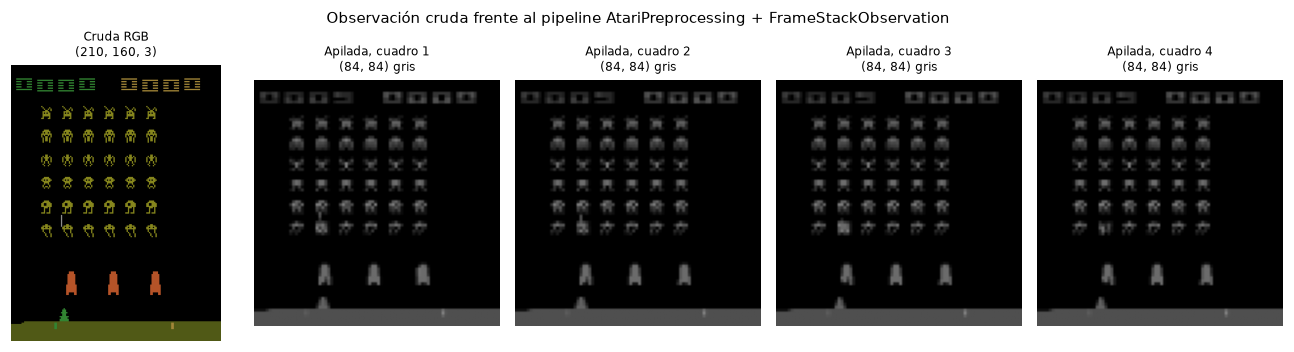

In [9]:
# Comparacion visual: imagen cruda frente a los 4 cuadros apilados que ve la red.
crudo = gym.make(ENTORNO, render_mode="rgb_array")
obs_cruda, _ = crudo.reset(seed=0)
for _ in range(40):
    obs_cruda, *_ = crudo.step(crudo.action_space.sample())
crudo.close()

obs_apilada, _ = apilado.reset(seed=0)
for _ in range(40):
    obs_apilada, *_ = apilado.step(apilado.action_space.sample())

fig, ejes = plt.subplots(1, 5, figsize=(12, 3.2))
ejes[0].imshow(obs_cruda)
ejes[0].set_title(f"Cruda RGB\n{obs_cruda.shape}", fontsize=8)
for i in range(4):
    ejes[i + 1].imshow(obs_apilada[i], cmap="gray", vmin=0, vmax=255)
    ejes[i + 1].set_title(f"Apilada, cuadro {i+1}\n(84, 84) gris", fontsize=8)
for eje in ejes:
    eje.axis("off")
fig.suptitle("Observación cruda frente al pipeline AtariPreprocessing + FrameStackObservation", fontsize=10)
fig.tight_layout()
fig.savefig(CARPETA_FIGURAS / "observacion_preprocesada.png", bbox_inches="tight")
plt.show()
apilado.close()

La observación final es **3.6 veces más pequeña** que la imagen original (28 224 valores
frente a 100 800) y aun así contiene **más información útil**, porque incorpora cuatro
instantes de tiempo en lugar de uno. Ese es exactamente el resultado que se busca: menos
datos, mejor estado.

## 3. Módulo de desarrollo: funciones para interactuar con ALE

Las funciones viven en [`src/ale_utils.py`](../src/ale_utils.py). Se importan aquí y se
demuestra cada una por separado.

In [10]:
from ale_utils import (
    crear_entorno,
    agente_aleatorio,
    agente_regla_simple,
    ejecutar_episodio,
    generar_video_agente,
)

### 3.1 `crear_entorno`

Crea el entorno y, si se le pasa `video_folder`, lo envuelve en
`gymnasium.wrappers.RecordVideo` con el `episode_trigger` indicado. Es **genérica**: acepta
cualquier id registrado y reenvía `**kwargs` a `gym.make`.

In [11]:
# Sin grabacion, para Space Invaders.
entorno = crear_entorno(ENTORNO)
print("Space Invaders  ->", type(entorno).__name__, "|", entorno.observation_space, entorno.action_space)
entorno.close()

# La misma funcion sirve para cualquier otro entorno de Gymnasium.
entorno = crear_entorno("CartPole-v1")
print("CartPole-v1     ->", type(entorno).__name__, "|", entorno.observation_space, entorno.action_space)
entorno.close()

# Y reenvia kwargs a gym.make.
entorno = crear_entorno(ENTORNO, obs_type="ram", full_action_space=True)
print("RAM + 18 acc.   ->", entorno.observation_space, entorno.action_space)
entorno.close()

# Con grabacion: el entorno queda envuelto en RecordVideo.
import shutil, tempfile

carpeta_demo = tempfile.mkdtemp()
entorno = crear_entorno(ENTORNO, video_folder=carpeta_demo, name_prefix="demo")
print("con video       ->", type(entorno).__name__, "->", type(entorno.env).__name__)
entorno.close()
shutil.rmtree(carpeta_demo)

Space Invaders  -> OrderEnforcing | Box(0, 255, (210, 160, 3), uint8) Discrete(6)
CartPole-v1     -> TimeLimit | Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32) Discrete(2)
RAM + 18 acc.   -> Box(0, 255, (128,), uint8) Discrete(18)


con video       -> RecordVideo -> OrderEnforcing


/home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/lab5/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /tmp/tmp_v50i0tx folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


### 3.2 `agente_aleatorio` y `agente_regla_simple`

`agente_aleatorio` es la **línea base**: ignora la observación y devuelve
`env.action_space.sample()`.

`agente_regla_simple` es una política fija, **sin aprendizaje**, con tres reglas:

1. Localiza el cañón y los invasores **por su color** en la imagen.
2. **Descarta los invasores cuya columna está tapada por un búnker**: disparar ahí destruye
   la propia cobertura en lugar de sumar puntos.
3. Se desplaza hacia el invasor alcanzable más cercano **disparando a la vez**
   (`RIGHTFIRE` / `LEFTFIRE`), y dispara sin moverse cuando ya está apuntando.

La tolerancia de apuntado es de 4 px, **media anchura de un invasor**. Y no esquiva los
proyectiles enemigos, no por simplificar sino porque —como se midió en la sección 1.4— con
el `frameskip=4` por defecto **son invisibles en la observación**.

In [12]:
entorno = crear_entorno(ENTORNO)
obs, _ = entorno.reset(seed=0)
for _ in range(40):
    obs, *_ = entorno.step(0)

significados = entorno.unwrapped.get_action_meanings()
print("aleatorio    ->", [significados[agente_aleatorio(obs, entorno)] for _ in range(10)])
print("regla simple ->", significados[agente_regla_simple(obs, entorno)],
      "(determinista para una misma observación)")
entorno.close()

aleatorio    -> ['RIGHT', 'LEFT', 'LEFTFIRE', 'RIGHT', 'NOOP', 'RIGHT', 'RIGHT', 'RIGHTFIRE', 'RIGHT', 'LEFTFIRE']
regla simple -> FIRE (determinista para una misma observación)


### 3.3 `ejecutar_episodio`

Ejecuta un episodio completo hasta que `terminated` o `truncated` sean verdaderos, o hasta
alcanzar `max_steps`, y devuelve **el número de pasos y el retorno acumulado**.

In [13]:
entorno = crear_entorno(ENTORNO)
pasos, retorno = ejecutar_episodio(entorno, agente_aleatorio, seed=0)
entorno.close()
print(f"agente aleatorio, semilla 0 -> {pasos} pasos, retorno {retorno}")

# max_steps corta el episodio antes de que termine solo.
entorno = crear_entorno(ENTORNO)
pasos, retorno = ejecutar_episodio(entorno, agente_aleatorio, max_steps=50, seed=0)
entorno.close()
print(f"con max_steps=50            -> {pasos} pasos, retorno {retorno}")

agente aleatorio, semilla 0 -> 298 pasos, retorno 35.0
con max_steps=50            -> 50 pasos, retorno 0.0


### 3.4 `generar_video_agente`

Función de alto nivel: crea el entorno **con grabación**, ejecuta `n_episodios` episodios
completos, **cierra el entorno** —sin ese `close()` el `.mp4` se queda a medias y no llega a
escribirse a disco— y devuelve las rutas de los videos junto con las métricas de cada episodio.

In [14]:
rutas_aleatorio, metricas_aleatorio = generar_video_agente(
    nombre_entorno=ENTORNO,
    funcion_agente=agente_aleatorio,
    video_folder=str(CARPETA_VIDEOS),
    name_prefix="aleatorio_spaceinvaders",
    n_episodios=1,
    seed=0,
)
rutas_aleatorio, metricas_aleatorio

/home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/lab5/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/lab5/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


(['/home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/lab5/videos/aleatorio_spaceinvaders-episode-0.mp4'],
 [{'episodio': 0,
   'entorno': 'ALE/SpaceInvaders-v5',
   'agente': 'agente_aleatorio',
   'semilla': 0,
   'pasos': 298,
   'recompensa_total': 35.0,
   'video': '/home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/lab5/videos/aleatorio_spaceinvaders-episode-0.mp4'}])

## 4. Videos generados

El entregable obligatorio es **al menos un video de un episodio completo del agente
aleatorio** en `ALE/SpaceInvaders-v5`. Se graba además un episodio del agente de regla
simple para poder comparar el comportamiento en video, no solo en números.

In [15]:
rutas_regla, metricas_regla = generar_video_agente(
    nombre_entorno=ENTORNO,
    funcion_agente=agente_regla_simple,
    video_folder=str(CARPETA_VIDEOS),
    name_prefix="regla_simple_spaceinvaders",
    n_episodios=1,
    seed=0,
)
rutas_regla

['/home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/lab5/videos/regla_simple_spaceinvaders-episode-0.mp4']

In [16]:
# Metricas de cada video generado: pasos sobrevividos y recompensa total del episodio.
videos = pd.DataFrame(metricas_aleatorio + metricas_regla)
videos["video"] = videos["video"].apply(lambda r: Path(r).name if r else None)
videos = videos[["agente", "entorno", "semilla", "pasos", "recompensa_total", "video"]]
videos

,agente,entorno,semilla,pasos,recompensa_total,video
0,agente_aleatorio,ALE/SpaceInvaders-v5,0,298,35.0,aleatorio_spaceinvaders-episode-0.mp4
1,agente_regla_simple,ALE/SpaceInvaders-v5,0,552,260.0,regla_simple_spaceinvaders-episode-0.mp4


In [17]:
# Comprobacion de que los .mp4 existen de verdad y no estan vacios.
for ruta in rutas_aleatorio + rutas_regla:
    archivo = Path(ruta)
    print(f"{archivo.name:44} {archivo.stat().st_size/1024:8.1f} KB")

aleatorio_spaceinvaders-episode-0.mp4            63.7 KB
regla_simple_spaceinvaders-episode-0.mp4        130.9 KB


## 5. Comparación de los dos agentes

Un solo episodio no dice gran cosa: con *sticky actions* y semillas distintas la varianza es
alta. Se ejecutan 10 episodios por agente con las mismas semillas, **sin grabar video**,
para comparar sobre una base justa.

In [18]:
SEMILLAS = list(range(10))
registros = []
for nombre, funcion in [("aleatorio", agente_aleatorio), ("regla_simple", agente_regla_simple)]:
    for semilla in SEMILLAS:
        entorno = crear_entorno(ENTORNO)
        pasos, retorno = ejecutar_episodio(entorno, funcion, seed=semilla)
        entorno.close()
        registros.append({"agente": nombre, "semilla": semilla, "pasos": pasos, "retorno": retorno})

episodios = pd.DataFrame(registros)
resumen = episodios.groupby("agente").agg(
    retorno_medio=("retorno", "mean"), retorno_min=("retorno", "min"),
    retorno_max=("retorno", "max"), retorno_std=("retorno", "std"),
    pasos_medios=("pasos", "mean"),
).round(1)
resumen

,retorno_medio,retorno_min,retorno_max,retorno_std,pasos_medios
agente,,,,,
aleatorio,123.5,30.0,235.0,73.3,461.0
regla_simple,246.0,155.0,285.0,34.8,522.1


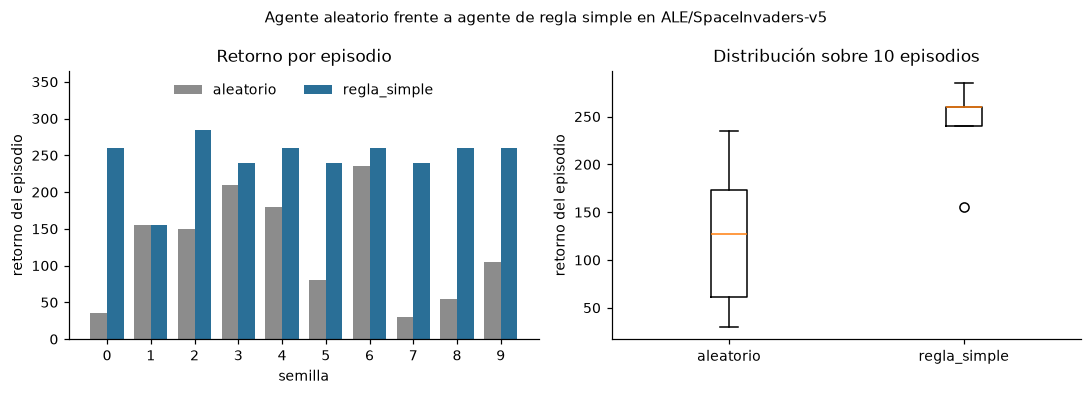

In [19]:
fig, (izq, der) = plt.subplots(1, 2, figsize=(10, 3.6))

ancho = 0.38
for i, (nombre, color) in enumerate([("aleatorio", "#8c8c8c"), ("regla_simple", "#2a6f97")]):
    datos = episodios[episodios.agente == nombre]
    izq.bar(np.array(SEMILLAS) + (i - 0.5) * ancho, datos["retorno"], ancho, label=nombre, color=color)
izq.set_xlabel("semilla"); izq.set_ylabel("retorno del episodio")
izq.set_title("Retorno por episodio"); izq.set_xticks(SEMILLAS)
izq.set_ylim(0, episodios["retorno"].max() * 1.28)
izq.legend(frameon=False, ncol=2, loc="upper center")

der.boxplot([episodios[episodios.agente == n]["retorno"] for n in ["aleatorio", "regla_simple"]],
            tick_labels=["aleatorio", "regla_simple"])
der.set_ylabel("retorno del episodio")
der.set_title(f"Distribución sobre {len(SEMILLAS)} episodios")

for eje in (izq, der):
    eje.spines[["top", "right"]].set_visible(False)
fig.suptitle("Agente aleatorio frente a agente de regla simple en ALE/SpaceInvaders-v5", fontsize=10)
fig.tight_layout()
fig.savefig(CARPETA_FIGURAS / "comparacion_agentes.png", bbox_inches="tight")
plt.show()

In [20]:
# Politica degenerada de control: quedarse quieto disparando siempre.
# Sirve para saber cuanto del merito del agente de regla simple viene de apuntar
# y cuanto de simplemente no dejar de disparar.
def agente_solo_disparar(observation, env):
    return env.unwrapped.get_action_meanings().index("FIRE")

retornos_disparar = []
for semilla in SEMILLAS:
    entorno = crear_entorno(ENTORNO)
    _, retorno = ejecutar_episodio(entorno, agente_solo_disparar, seed=semilla)
    entorno.close()
    retornos_disparar.append(retorno)

print(f"solo disparar -> retorno medio {np.mean(retornos_disparar):.1f} "
      f"(min {min(retornos_disparar):.0f}, max {max(retornos_disparar):.0f})")

solo disparar -> retorno medio 285.0 (min 285, max 285)


In [21]:
# Se guardan las metricas para que el informe no dependa de volver a ejecutar el notebook.
import json

resultados = {
    "entorno": ENTORNO,
    "versiones": {"gymnasium": gym.__version__, "ale_py": ale_py.__version__},
    "videos": [
        {k: (Path(v).name if k == "video" and v else v) for k, v in m.items()}
        for m in metricas_aleatorio + metricas_regla
    ],
    "episodios": registros,
    "resumen": resumen.to_dict(orient="index"),
    "control_solo_disparar": {
        "retorno_medio": float(np.mean(retornos_disparar)),
        "retornos": retornos_disparar,
    },
}
ruta_resultados = RAIZ / "results" / "summary.json"
ruta_resultados.write_text(json.dumps(resultados, indent=2, ensure_ascii=False))
print("guardado en", ruta_resultados.relative_to(RAIZ))

guardado en results/summary.json


## 6. Conclusiones

**Sobre la infraestructura**, que es el objetivo del laboratorio:

- El módulo deja cerrado el ciclo completo: crear el entorno, envolverlo en `RecordVideo`,
  ejecutar episodios con cualquier función de agente y obtener el `.mp4` junto con las
  métricas. `crear_entorno` no está atada a Atari, así que el mismo código sirve para
  CartPole o para los entornos de laboratorios siguientes.
- Tres cosas que rompen el montaje si se pasan por alto: **registrar los entornos** con
  `gym.register_envs(ale_py)`, crear el entorno con **`render_mode="rgb_array"`**, y llamar a
  **`env.close()`** al terminar, porque sin él el video no se escribe a disco.

**Sobre los agentes:**

- El agente de regla simple **duplica aproximadamente el retorno del aleatorio** y con mucha
  menos varianza, sin haber aprendido nada: solo mirando colores en la imagen.
- Pero la política degenerada de **quedarse quieto disparando** puntúa en el mismo orden de
  magnitud. Es un resultado incómodo y vale la pena decirlo: buena parte del mérito no está
  en apuntar, sino en **no dejar de disparar nunca**, porque la formación de invasores acaba
  pasando por encima del cañón de todos modos. Moverse, además, tiene un costo real: con
  *sticky actions* el movimiento es impreciso, y sobre todo **es a ciegas**, porque las
  bombas enemigas no aparecen en la observación.
- Ese último punto conecta las dos mitades del laboratorio. La medición de la sección 1.4
  —los proyectiles son invisibles con `frameskip=4` sin *max-pooling*— **no es un detalle
  teórico**: es exactamente lo que le impide a este agente esquivar. El preprocesamiento
  estándar de Atari no es burocracia, resuelve un problema que aquí se puede tocar con la mano.

**Lo que falta para un agente que sí aprenda:** apilar `AtariPreprocessing` y
`FrameStackObservation` sobre `crear_entorno` (la sección 2.4 ya muestra el pipeline),
añadir el recorte de recompensa y sustituir la función de agente por una red que estime
Q(s,a). La infraestructura de este laboratorio no cambia: solo cambia `funcion_agente`.